In [1]:
import pandas as pd
import matplotlib.pyplot as plt


In [2]:
llms = ["gpt-4o", "gpt-4o-mini", "Meta-Llama-3.1-8B-Instruct", "Meta-Llama-3.1-70B-Instruct"]
llm_names = ["GPT-4o", "GPT-4o Mini", "Llama 3.1 8B", "Llama 3.1 70B"]
data_folder = "data/"
tasks = ["taxonomy", "activity", "programs"]

In [3]:
runtime_results = {}

for task in tasks:
    folder = f"{data_folder}{task}"
    task_results = []
    for llm in llms:
        df = pd.read_csv(f"{folder}/{llm}_runtime_abscon_10.csv")
        df["embedding_runtime_total"] = df["embedding_runtime"].apply(lambda x: sum(eval(x)))
        df["graph_matching_runtime_total"] = df["graph_matching_runtime"].apply(lambda x: sum(eval(x)))
        df["total_runtime"] = df["embedding_runtime_total"] + df["graph_matching_runtime_total"] + df["problem_build_runtimes"] + df["problem_solve_runtimes"]
        task_results.append(df)
    runtime_results[task] = task_results    

In [4]:
runtime_results.keys()

dict_keys(['taxonomy', 'activity', 'programs'])

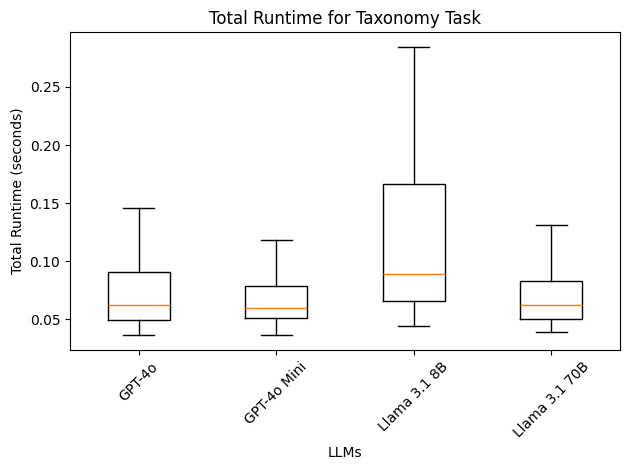

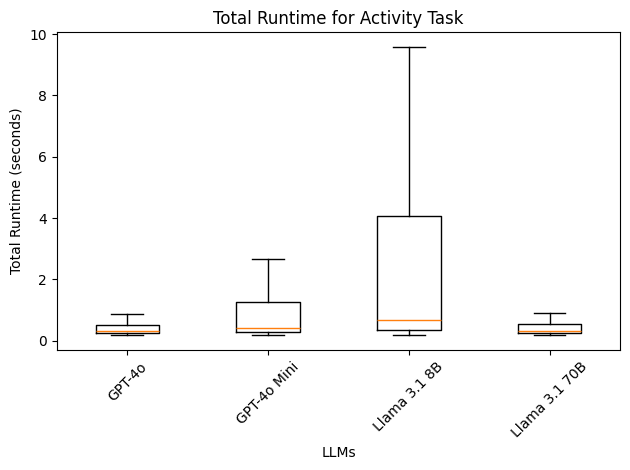

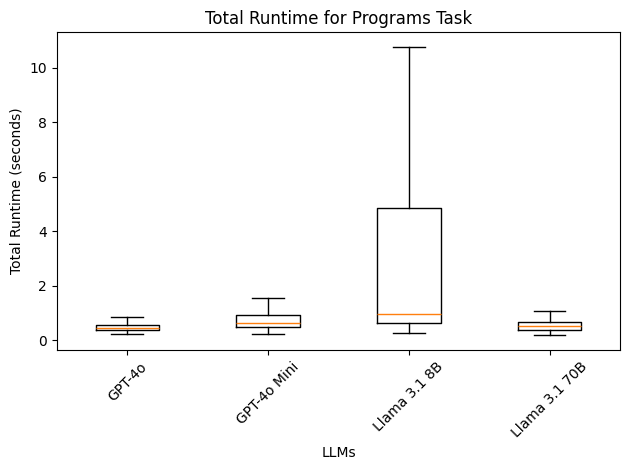

In [5]:
for task, task_data in runtime_results.items():
    data = [df["total_runtime"].values for df in task_data]
    # plt.figure(figsize=(10, 5))
    plt.boxplot(data, tick_labels=llm_names, showfliers=False)
    plt.title(f"Total Runtime for {task.capitalize()} Task")
    plt.ylabel("Total Runtime (seconds)")
    plt.xlabel("LLMs")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.savefig(f"{task}_total_runtime_boxplot.png")
    plt.show()

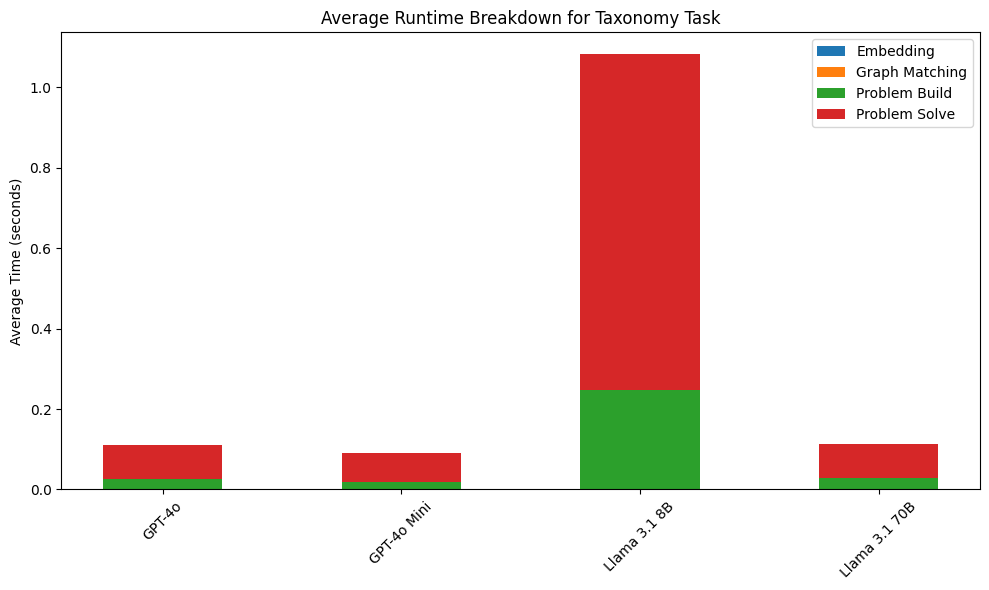

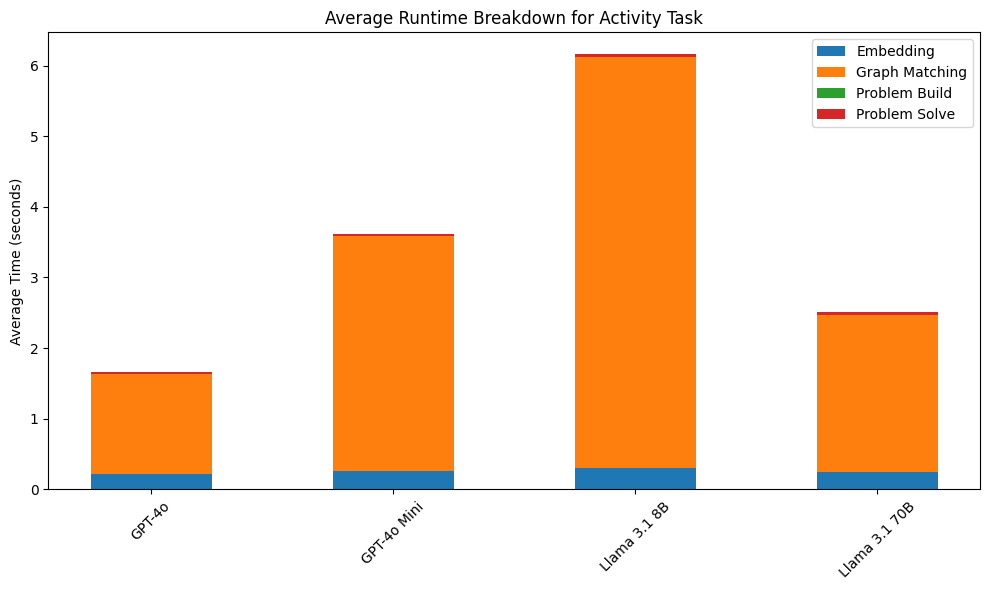

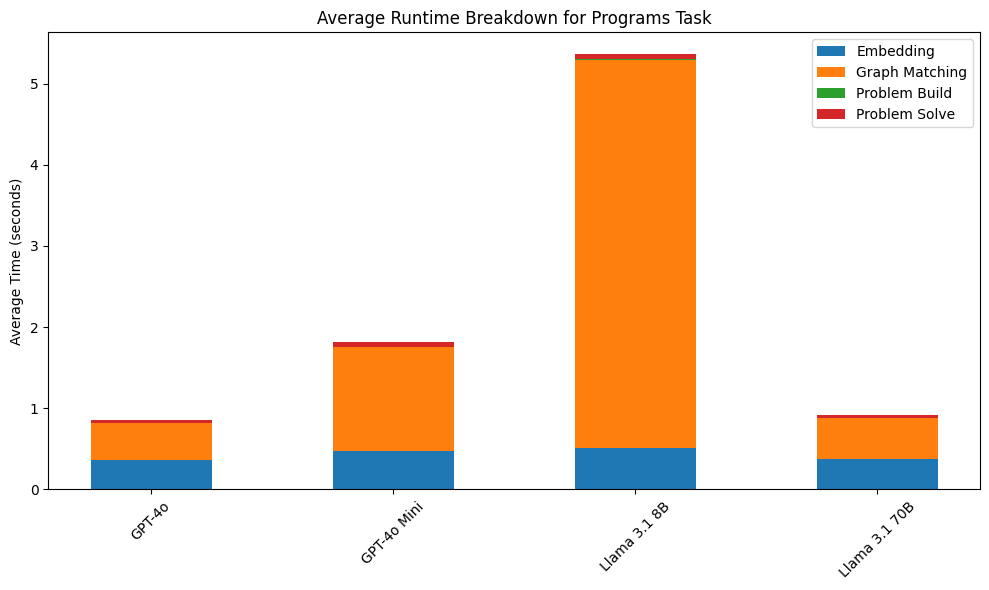

In [6]:
# Plot a stacked barchart for the total runtime breakdown for each task and LLM

for task, task_data in runtime_results.items():
    labels = llm_names
    embedding_times = {
        "embedding": [task_data[i]["embedding_runtime_total"].mean() for i in range(len(llm_names))],
        "graph_matching": [task_data[i]["graph_matching_runtime_total"].mean() for i in range(len(llm_names))],
        "problem_build": [task_data[i]["problem_build_runtimes"].mean() for i in range(len(llm_names))],
        "problem_solve": [task_data[i]["problem_solve_runtimes"].mean() for i in range(len(llm_names))],
    }

    width = 0.5

    fig, ax = plt.subplots(figsize=(10, 6))
    bottom = [0] * len(labels)

    for component, times in embedding_times.items():
        ax.bar(labels, times, width, label=component.replace("_", " ").title(), bottom=bottom)
        bottom = [bottom[i] + times[i] for i in range(len(times))]
    ax.set_ylabel('Average Time (seconds)')
    ax.set_title(f'Average Runtime Breakdown for {task.capitalize()} Task')
    ax.legend()
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.savefig(f"{task}_runtime_breakdown_stacked_bar.png")
    plt.show()

## Check the relation between entropy and runtime

In [7]:
import pickle
import numpy as np


In [49]:
task_partial_models = {}

for task in tasks:
    folder = f"{data_folder}{task}"
    task_partial_models[task] = []
    for llm in llms:
        filename = f"{folder}/{llm}_partial_models_10.pkl"
        with open(filename, "rb") as f:
            partial_models = pickle.load(f)
        task_partial_models[task].append(partial_models)

num_candidates = 10

# convert the partial model weight to probability
for task, task_partiam_models in task_partial_models.items():
    for partial_models in task_partiam_models:
        for partial_model in partial_models:
            for node, data in partial_model.nodes(data=True):
                if "weight" in data:
                    data["weight"] = data["weight"] / num_candidates
            for u, v, data in partial_model.edges(data=True):
                if "weight" in data:
                    data["weight"] = data["weight"] / num_candidates
        

In [50]:
def calculate_entropy(partial_models):
    entropies = []
    for partial_model in partial_models:
        node_weights = np.array([data["weight"] for _, data in partial_model.nodes(data=True) if "weight" in data])
        edge_weights = np.array([data["weight"] for _, _, data in partial_model.edges(data=True) if "weight" in data])
        weights = np.concatenate((node_weights, edge_weights))

        if len(weights) > 0:
            # Each weight corresponds to a probability of a binary event
            # Adding a small constant to avoid log(0)
            # value = (-np.sum(weights * np.log2(weights + 1e-10)) - np.sum((1 - weights) * np.log2(1 - weights + 1e-10)))
            
            # calculate the number of non-1 weights
            value = (weights != 1).sum()
            entropies.append(value)
    return entropies

In [51]:
task_entropies = {}

for task, task_partial_models in task_partial_models.items():
    task_entropies[task] = []
    for partial_models in task_partial_models:
        entropies = calculate_entropy(partial_models)
        task_entropies[task].append(entropies)

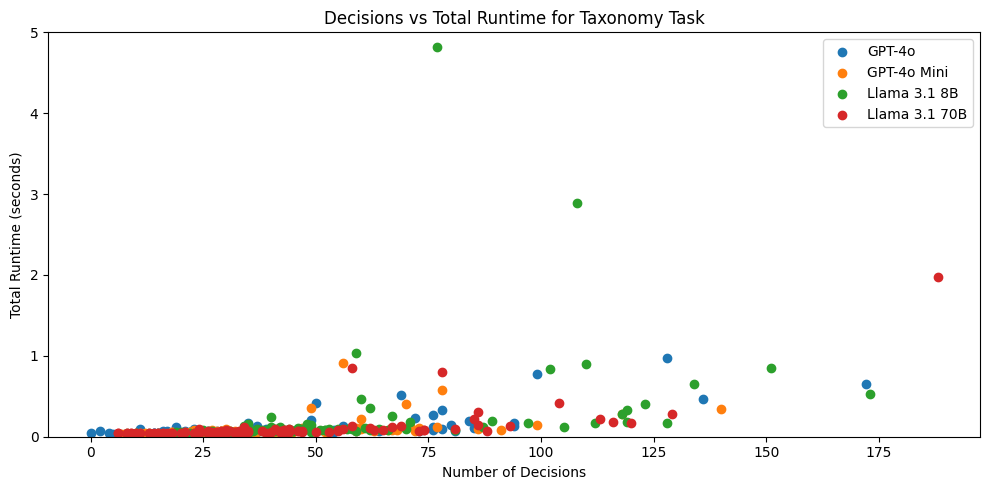

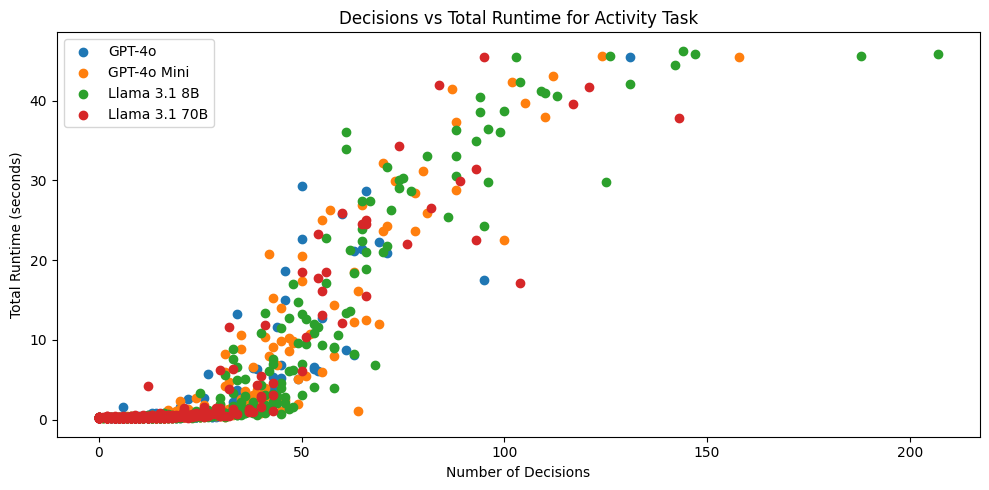

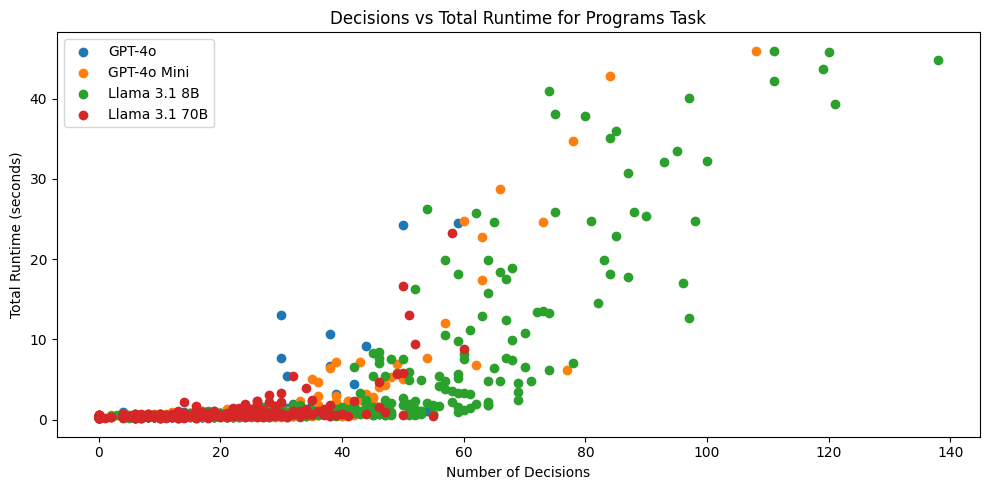

In [55]:
# Plotting the scatter plot for entropy and total runtime on the same graph for each task with different colors for each LLM
for task, task_data in runtime_results.items():
    plt.figure(figsize=(10, 5))
    for i, (llm, df) in enumerate(zip(llm_names, task_data)):
        entropies = task_entropies[task][i]
        total_runtime = df["total_runtime"].values
        plt.scatter(entropies, total_runtime, label=llm)
    
    plt.title(f"Decisions vs Total Runtime for {task.capitalize()} Task")
    plt.xlabel("Number of Decisions")
    plt.ylabel("Total Runtime (seconds)")
    plt.legend()

    if task == "taxonomy":
        plt.ylim(0, 5)

    plt.tight_layout()
    plt.savefig(f"{task}_entropy_vs_runtime.png")
    plt.show()

In [53]:
# Check the correlation between entropy and runtime for each task
from scipy.stats import pearsonr, spearmanr


In [54]:
# Check the correlation between entropy and runtime for each task
for task, task_data in runtime_results.items():
    total_runtimes = []
    entropies = []
    for i, (llm, df) in enumerate(zip(llm_names, task_data)):
        entropies.extend(task_entropies[task][i])
        total_runtimes.extend(df["total_runtime"].values)
    
    pearson_corr, pearson_p = pearsonr(entropies, total_runtimes)
    spearman_corr, spearman_p = spearmanr(entropies, total_runtimes)
    print(f"Task: {task.capitalize()}")
    print(f"Pearson correlation: {pearson_corr:.4f} (p-value: {pearson_p:.4f})")
    print(f"Spearman correlation: {spearman_corr:.4f} (p-value: {spearman_p:.4f})")

Task: Taxonomy
Pearson correlation: 0.2453 (p-value: 0.0000)
Spearman correlation: 0.8250 (p-value: 0.0000)
Task: Activity
Pearson correlation: 0.8800 (p-value: 0.0000)
Spearman correlation: 0.8762 (p-value: 0.0000)
Task: Programs
Pearson correlation: 0.7042 (p-value: 0.0000)
Spearman correlation: 0.7642 (p-value: 0.0000)


## Graph Matching Runtime v.s. Number of candidates

In [97]:
task_graph_matching_time = {}
for task, task_data in runtime_results.items():
    task_graph_matching_time[task] = []
    for i, (llm, df) in enumerate(zip(llm_names, task_data)):
        embedding_runtimes = df["graph_matching_runtime"].apply(lambda x: eval(x)).tolist()
        task_graph_matching_time[task].append(embedding_runtimes)

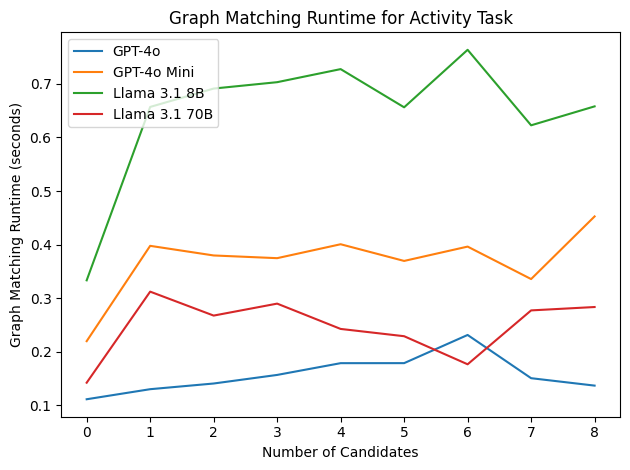

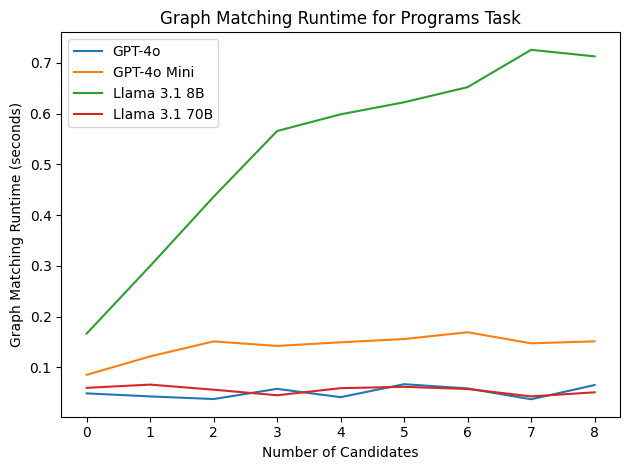

In [99]:
# Plotting the runtime distribution for each LLM and each task
for task, task_data in task_graph_matching_time.items():
    if task == "taxonomy":
        continue
    for i, (llm, runtimes) in enumerate(zip(llm_names, task_data)):
        x_range = range(9)
        y_data = []
        for i in x_range:
            candidate_runtimes = [r[i] for r in runtimes if len(r) > i]
            y_data.append(np.mean(candidate_runtimes))
        plt.plot(x_range, y_data, label=llm)
    plt.title(f"Graph Matching Runtime for {task.capitalize()} Task")
    plt.xlabel("Number of Candidates")
    plt.ylabel("Graph Matching Runtime (seconds)")
    plt.xticks(x_range, [str(i) for i in x_range])
    plt.legend()
    plt.tight_layout()
    plt.savefig(f"{task}_graph_matching_runtime.png")
    plt.show()